In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")

EDA

In [41]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [42]:
df.tail()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015
1435,6950,76,1,Petrol,110,0,1600,5,4,5,1114


In [43]:
df.shape

(1436, 11)

In [44]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [45]:
df.isnull().sum()


Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

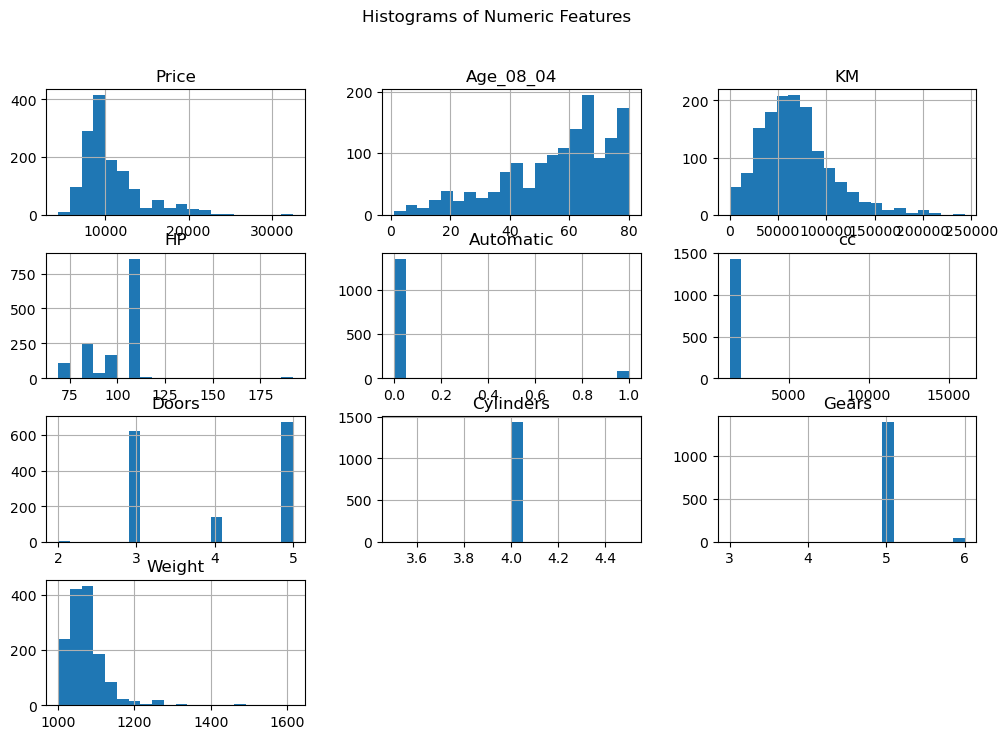

In [46]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

df[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Histograms of Numeric Features")
plt.show()

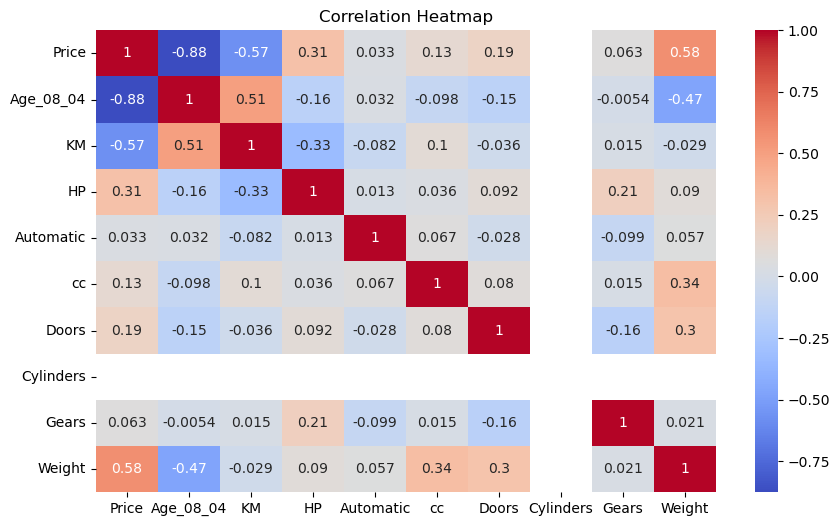

In [47]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

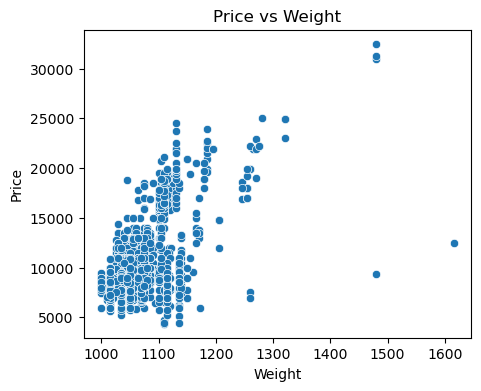

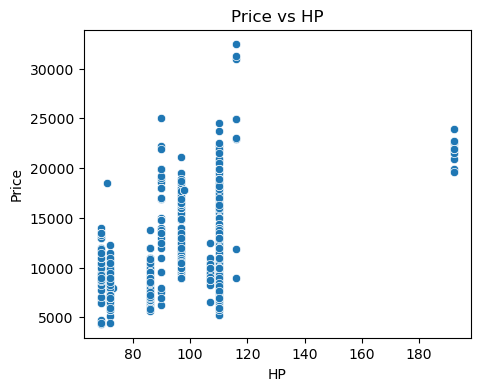

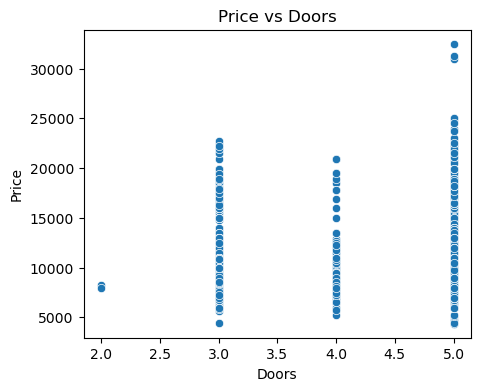

In [48]:
corr = df[numeric_cols].corr()['Price'].sort_values(ascending=False)
top_corr_features = corr.index[1:4]  # Top 3 predictors

for col in top_corr_features:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=df[col], y=df['Price'])
    plt.title(f"Price vs {col}")
    plt.show()

In [49]:
df['Doors'] = df['Doors'].astype(str).str.extract('(\d+)').astype(float)
df['Doors'] 

0       3.0
1       3.0
2       3.0
3       3.0
4       3.0
       ... 
1431    3.0
1432    3.0
1433    3.0
1434    3.0
1435    5.0
Name: Doors, Length: 1436, dtype: float64

In [50]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True,dtype=int)


In [51]:
df = df.dropna()

In [52]:
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3.0,4,5,1165,1,0
1,13750,23,72937,90,0,2000,3.0,4,5,1165,1,0
2,13950,24,41711,90,0,2000,3.0,4,5,1165,1,0
3,14950,26,48000,90,0,2000,3.0,4,5,1165,1,0
4,13750,30,38500,90,0,2000,3.0,4,5,1170,1,0


In [53]:
df.shape

(1436, 12)

Train-Test Split

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [57]:
X_train.shape

(1148, 11)

In [58]:
X_test.shape

(288, 11)

Build THREE Different  Models

In [59]:
from sklearn.linear_model import LinearRegression

In [60]:
model1 = LinearRegression()
model1.fit(X_train, y_train)


LinearRegression()

In [61]:
y_pred_m1 = model1.predict(X_test)

In [62]:
print("Model 1 Coefficients:")
for name, coef in zip(X_train.columns, model1.coef_):
    print(name, ":", coef)

Model 1 Coefficients:
Age_08_04 : -120.83045817097121
KM : -0.016231410612674215
HP : 14.039478769759071
Automatic : 148.83092691182213
cc : -0.030372194607026344
Doors : -60.310974374988625
Cylinders : -1.1084466677857563e-12
Gears : 551.6007102659836
Weight : 25.884958313274517
Fuel_Type_Diesel : -68.54875675828676
Fuel_Type_Petrol : 1370.8089098159796


In [63]:
top_features = corr.index[1:5]  # Choose top 4 predictors

print("Top Features Used in Model 2:", top_features.tolist())



Top Features Used in Model 2: ['Weight', 'HP', 'Doors', 'cc']


In [64]:
X2_train = X_train[top_features]
X2_test  = X_test[top_features]



In [65]:
model2 = LinearRegression()
model2.fit(X2_train, y_train)



LinearRegression()

In [68]:
y_pred_m2 = model2.predict(X2_test)


In [78]:
print("\nMODEL 2 — Coefficients (Reduced MLR):")
for name, coef in zip(top_features, model2.coef_):
    print(f"{name}: {coef:.4f}")


MODEL 2 — Coefficients (Reduced MLR):
Weight: 42.2072
HP: 65.3169
Doors: -28.9275
cc: -0.6249


In [72]:
from sklearn.preprocessing import StandardScaler

In [73]:
scaler = StandardScaler()

In [74]:
X3_train = scaler.fit_transform(X_train)
X3_test  = scaler.transform(X_test)

In [75]:
model3 = LinearRegression()
model3.fit(X3_train, y_train)


LinearRegression()

In [76]:
y_pred_m3 = model3.predict(X3_test)

In [77]:
print("Model 3 Coefficients (Standardized):")
for name, coef in zip(X_train.columns, model3.coef_):
    print(name, ":", coef)

Model 3 Coefficients (Standardized):
Age_08_04 : -2267.294782506099
KM : -611.6544115414325
HP : 208.349857890824
Automatic : 34.397129788617086
cc : -14.16191663402139
Doors : -57.46780385451866
Cylinders : -1.7053025658242404e-13
Gears : 109.34041695045455
Weight : 1316.8183107641698
Fuel_Type_Diesel : -21.722172573582583
Fuel_Type_Petrol : 458.04773146967756


Evaluate All 3 MLR Models

In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [80]:
def evaluate(name, y_true, y_pred):
    print(f"\n{name} RESULTS:")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²   :", r2_score(y_true, y_pred))

In [81]:
evaluate("MODEL 1 — Full MLR", y_test, y_pred_m1)
evaluate("MODEL 2 — Reduced MLR", y_test, y_pred_m2)
evaluate("MODEL 3 — Standardized MLR", y_test, y_pred_m3)


MODEL 1 — Full MLR RESULTS:
MAE : 990.8872739193927
RMSE: 1484.2654153296514
R²   : 0.8348888040611082

MODEL 2 — Reduced MLR RESULTS:
MAE : 2082.796917983211
RMSE: 2830.756919004489
R²   : 0.39943704210875897

MODEL 3 — Standardized MLR RESULTS:
MAE : 990.887273919397
RMSE: 1484.2654153296517
R²   : 0.8348888040611082


Lasso & Ridge

In [82]:
from sklearn.linear_model import LassoCV


In [83]:
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)

LassoCV(cv=5, random_state=42)

In [84]:
y_pred_lasso = lasso.predict(X_test)

In [85]:
evaluate("LASSO Regression", y_test, y_pred_lasso)
print("Best Lasso Alpha:", lasso.alpha_)



LASSO Regression RESULTS:
MAE : 2123.195257892171
RMSE: 2952.1195577649205
R²   : 0.34683745763900653
Best Lasso Alpha: 191963.01183701464


In [87]:
from sklearn.linear_model import RidgeCV


In [88]:
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X_train, y_train)

RidgeCV(alphas=array([1.00000000e-03, 1.32571137e-03, 1.75751062e-03, 2.32995181e-03,
       3.08884360e-03, 4.09491506e-03, 5.42867544e-03, 7.19685673e-03,
       9.54095476e-03, 1.26485522e-02, 1.67683294e-02, 2.22299648e-02,
       2.94705170e-02, 3.90693994e-02, 5.17947468e-02, 6.86648845e-02,
       9.10298178e-02, 1.20679264e-01, 1.59985872e-01, 2.12095089e-01,
       2.81176870e-01, 3.72759372e-0...
       8.68511374e-01, 1.15139540e+00, 1.52641797e+00, 2.02358965e+00,
       2.68269580e+00, 3.55648031e+00, 4.71486636e+00, 6.25055193e+00,
       8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
       2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
       7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
       2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
       7.54312006e+02, 1.00000000e+03]),
        cv=5)

In [89]:
y_pred_ridge = ridge.predict(X_test)

In [90]:
evaluate("Ridge Regression", y_test, y_pred_ridge)
print("Best Ridge Alpha:", ridge.alpha_)



Ridge Regression RESULTS:
MAE : 995.8357671458928
RMSE: 1415.9138208503853
R²   : 0.8497456587554802
Best Ridge Alpha: 1000.0


Interview Question

1.What is Normalization & Standardization and how is it helpful?
ans:Normalization means changing the values of a feature so they fall between 0 and 1.
This is useful when different columns in the dataset have very different ranges.
For example, “Age” may be from 20–60, but “Salary” may be from 20,000–90,000.
Normalization makes both features comparable.
Standardization means converting the data so it has a mean of 0 and a standard deviation of 1.
It does not squeeze values into 0–1, but it puts all features on the same scale.
Both methods help machine learning models work better because some algorithms get confused when features have very large differences in scale.
Scaling makes the model faster, more stable, and improves accuracy.

2.What techniques can be used to address multicollinearity in multiple linear regression?
Multicollinearity happens when two or more independent variables are highly correlated with each other.
This makes it hard for the model to understand which variable is actually affecting the output.
Ways to fix or reduce multicollinearity:
Remove one of the correlated features if they provide the same information.
Combine the features (for example, take an average or create a single new feature).
Use PCA to convert correlated features into new uncorrelated components.
Use Regularization techniques like Ridge or Lasso, which reduce the effect of multicollinearity.
Check VIF (Variance Inflation Factor) and drop features with very high VIF values.
Collect more data (if possible), which sometimes reduces the issue.